## ID Card Preprocessing Agents:



**Module A: System Architecture & Multi-Modal Design
"Walk me through your high-level architecture. How do you design a pipeline that extracts structured data (Name, DOB, Address) from a noisy Indonesian ID card while simultaneously detecting if the pixel patterns suggest a Photoshop manipulation**


**Image Preprocessing Agent Workflow:**

In [ ]:
START
  ↓
Boundary Detection Agent
  ↓
Background Removal + Warp Agent
  ↓
Glare / Blur Cleaning Agent
  ↓
Text Enhancement Agent
  ↓
OCR Agent
  ↓
END

In [ ]:
!pip install langgraph langchain opencv-python matplotlib

In [ ]:
pip install DeepFace

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.7 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END
import traceback
from google.colab import drive
import glob

##Read images from colab

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
class KTPState(TypedDict):
    image_path: str
    output_dir: str
    original_image: object
    card_points: object
    warped_path: str
    cleaned_path: str
    text_ready_path: str
    error: str

In [ ]:
def order_points(pts):
    try:
        # Validate input
        if pts is None:
            raise ValueError("Input points cannot be None.")

        pts = np.asarray(pts)

        if pts.shape != (4, 2):
            raise ValueError(f"Expected shape (4, 2), but got {pts.shape}")

        rect = np.zeros((4, 2), dtype="float32")

        # Top-left and bottom-right
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]

        # Top-right and bottom-left
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]
        rect[3] = pts[np.argmax(diff)]

        return rect

    except Exception as e:
        print(f"[ERROR] order_points(): {e}")
        traceback.print_exc()
        return None

In [ ]:
def four_point_transform(image, pts):
    try:
        # Validate inputs
        if image is None:
            raise ValueError("Input image is None.")

        rect = order_points(pts)

        if rect is None:
            raise ValueError("order_points() returned None.")

        tl, tr, br, bl = rect

        # Compute width
        width_a = np.linalg.norm(br - bl)
        width_b = np.linalg.norm(tr - tl)
        max_width = max(int(width_a), int(width_b))

        # Compute height
        height_a = np.linalg.norm(tr - br)
        height_b = np.linalg.norm(tl - bl)
        max_height = max(int(height_a), int(height_b))

        if max_width <= 0 or max_height <= 0:
            raise ValueError(
                f"Invalid dimensions: width={max_width}, height={max_height}"
            )

        # Destination points
        dst = np.array([
            [0, 0],
            [max_width - 1, 0],
            [max_width - 1, max_height - 1],
            [0, max_height - 1]
        ], dtype="float32")

        # Perspective transform
        matrix = cv2.getPerspectiveTransform(rect, dst)
        warped = cv2.warpPerspective(image, matrix, (max_width, max_height))

        return warped

    except Exception as e:
        print(f"[ERROR] four_point_transform(): {e}")
        traceback.print_exc()
        return None

In [ ]:
def boundary_detection_agent(state: KTPState):
    try:
        image = cv2.imread(state["image_path"])

        if image is None:
            raise ValueError(f"Image could not be read: {state['image_path']}")

        h, w = image.shape[:2]
        scale = 800 / max(h, w)
        resized = cv2.resize(image, (int(w * scale), int(h * scale)))

        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
        gray = cv2.equalizeHist(gray)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)

        edges = cv2.Canny(blur, 30, 120)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
        edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(
            edges,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        contours = sorted(contours, key=cv2.contourArea, reverse=True)

        card_points = None
        image_area = resized.shape[0] * resized.shape[1]

        for c in contours:
            area = cv2.contourArea(c)

            if area < 0.15 * image_area:
                continue

            peri = cv2.arcLength(c, True)
            approx = cv2.approxPolyDP(c, 0.03 * peri, True)

            if len(approx) == 4:
                card_points = approx.reshape(4, 2)
                break

        if card_points is None and len(contours) > 0:
            rect = cv2.minAreaRect(contours[0])
            card_points = cv2.boxPoints(rect)

        if card_points is None:
            raise ValueError("ID card boundary not detected.")

        card_points = card_points / scale

        return {
            "original_image": image,
            "card_points": card_points
        }

    except Exception as e:
        print(f"[ERROR] boundary_detection_agent(): {e}")
        traceback.print_exc()

        return {
            "error": str(e),
            "original_image": None,
            "card_points": None
        }

In [ ]:
def warp_agent(state: KTPState):
    try:
        image = state.get("original_image")
        points = state.get("card_points")

        if image is None:
            raise ValueError("Original image is missing.")

        if points is None:
            raise ValueError("Card points are missing.")

        warped = four_point_transform(image, points)

        if warped is None:
            raise ValueError("Perspective transformation failed.")

        h, w = warped.shape[:2]

        # Rotate if the image is in portrait mode
        if h > w:
            warped = cv2.rotate(warped, cv2.ROTATE_90_CLOCKWISE)

        # Create output directory
        output_dir = os.path.join(state["output_dir"], "warp")
        os.makedirs(output_dir, exist_ok=True)

        output_path = os.path.join(
            output_dir,
            os.path.basename(state["image_path"])
        )

        success = cv2.imwrite(output_path, warped)

        if not success:
            raise IOError(f"Failed to save image to {output_path}")

        return {
            "warped_path": output_path
        }

    except Exception as e:
        print(f"[ERROR] warp_agent(): {e}")
        traceback.print_exc()

        return {
            "error": str(e),
            "warped_path": None
        }

In [ ]:
def clean_agent(state: KTPState):
    try:
        warped_path = state.get("warped_path")

        if not warped_path:
            raise ValueError("warped_path is missing from state.")

        image = cv2.imread(warped_path)

        if image is None:
            raise ValueError(f"Unable to read image: {warped_path}")

        # Convert to LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)

        # Apply CLAHE
        clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )
        l = clahe.apply(l)

        enhanced = cv2.merge((l, a, b))
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

        # Denoise
        denoised = cv2.fastNlMeansDenoisingColored(
            enhanced,
            None,
            10,
            10,
            7,
            21
        )

        # Sharpen
        sharpen_kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])

        cleaned = cv2.filter2D(denoised, -1, sharpen_kernel)

        # Create output directory
        output_dir = os.path.join(state["output_dir"], "clean")
        os.makedirs(output_dir, exist_ok=True)

        output_path = os.path.join(
            output_dir,
            os.path.basename(state["image_path"])
        )

        success = cv2.imwrite(output_path, cleaned)

        if not success:
            raise IOError(f"Failed to save cleaned image to {output_path}")

        return {
            "cleaned_path": output_path
        }

    except Exception as e:
        print(f"[ERROR] clean_agent(): {e}")
        traceback.print_exc()

        return {
            "error": str(e),
            "cleaned_path": None
        }

In [ ]:
def text_enhancement_agent(state: KTPState):
    try:
        cleaned_path = state.get("cleaned_path")

        if not cleaned_path:
            raise ValueError("cleaned_path is missing from state.")

        image = cv2.imread(cleaned_path)

        if image is None:
            raise ValueError(f"Unable to read image: {cleaned_path}")

        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Improve local contrast
        clahe = cv2.createCLAHE(
            clipLimit=3.0,
            tileGridSize=(8, 8)
        )
        gray = clahe.apply(gray)

        # Create OCR-ready binary image
        text_ready = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            11
        )

        # Create output directory
        output_dir = os.path.join(state["output_dir"], "text_ready")
        os.makedirs(output_dir, exist_ok=True)

        output_path = os.path.join(
            output_dir,
            os.path.basename(state["image_path"])
        )

        success = cv2.imwrite(output_path, text_ready)

        if not success:
            raise IOError(f"Failed to save image to {output_path}")

        return {
            "text_ready_path": output_path
        }

    except Exception as e:
        print(f"[ERROR] text_enhancement_agent(): {e}")
        traceback.print_exc()

        return {
            "error": str(e),
            "text_ready_path": None
        }

In [ ]:
def should_continue(state: KTPState):
    if state.get("error"):
        return "end"
    return "continue"


workflow = StateGraph(KTPState)

workflow.add_node("boundary_detection_agent", boundary_detection_agent)
workflow.add_node("warp_agent", warp_agent)
workflow.add_node("clean_agent", clean_agent)
workflow.add_node("text_enhancement_agent", text_enhancement_agent)

workflow.set_entry_point("boundary_detection_agent")

workflow.add_conditional_edges(
    "boundary_detection_agent",
    should_continue,
    {
        "continue": "warp_agent",
        "end": END
    }
)

workflow.add_edge("warp_agent", "clean_agent")
workflow.add_edge("clean_agent", "text_enhancement_agent")
workflow.add_edge("text_enhancement_agent", END)

app = workflow.compile()

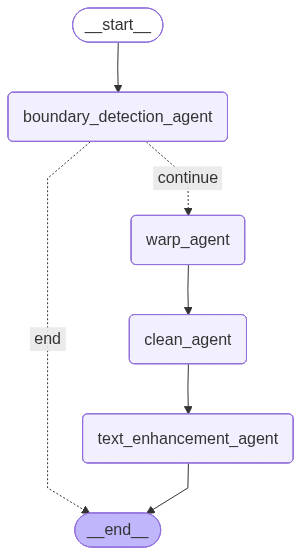

In [ ]:
app

## Run for one image

In [ ]:
result = app.invoke({
    "image_path": "/content/drive/MyDrive/kyc_train/train/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg",
    "output_dir": "/content/drive/My Drive/kyc_train/after_preprocess_image/",
    "error": ""
})

print(result)

{'image_path': '/content/drive/MyDrive/kyc_train/train/ab391159-ktp-16_jpg.rf.7f3da75ff655703144a959d241c2f881.jpg', 'output_dir': '/content/drive/My Drive/kyc_train/after_preprocess_image/', 'original_image': array([[[14, 16, 17],
        [12, 14, 15],
        [12, 14, 15],
        ...,
        [23, 25, 35],
        [24, 26, 36],
        [25, 27, 37]],

       [[11, 13, 14],
        [ 9, 11, 12],
        [ 9, 11, 12],
        ...,
        [26, 28, 38],
        [28, 30, 40],
        [29, 31, 41]],

       [[11, 13, 14],
        [ 9, 11, 12],
        [ 9, 11, 12],
        ...,
        [24, 26, 36],
        [26, 28, 38],
        [29, 31, 41]],

       ...,

       [[12, 17, 20],
        [14, 19, 22],
        [18, 23, 26],
        ...,
        [53, 51, 57],
        [51, 51, 57],
        [51, 51, 57]],

       [[23, 28, 31],
        [24, 29, 32],
        [25, 30, 33],
        ...,
        [46, 44, 50],
        [44, 44, 50],
        [44, 44, 50]],

       [[20, 25, 28],
        [19, 24, 27]

## Read Multiple Images:

In [ ]:
input_folder = "/content/drive/MyDrive/kyc_train/before_preprocess_image/"
output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/"

##Supports .jpg or .jpeg or .png

image_paths = (
    glob.glob(os.path.join(input_folder, "*.jpg")) +
    glob.glob(os.path.join(input_folder, "*.jpeg")) +
    glob.glob(os.path.join(input_folder, "*.png"))
)

print("Total images found:", len(image_paths))

results = []

for image_path in image_paths:
    try:
        result = app.invoke({
            "image_path": image_path,
            "output_dir": output_folder,
            "error": ""
        })

        results.append({
            "image_path": image_path,
            "status": "success",
            "warped_path": result.get("warped_path"),
            "cleaned_path": result.get("cleaned_path"),
            "text_ready_path": result.get("text_ready_path"),
            "error": result.get("error", "")
        })

        print("Processed:", os.path.basename(image_path))

    except Exception as e:
        results.append({
            "image_path": image_path,
            "status": "failed",
            "error": str(e)
        })

        print("Failed:", os.path.basename(image_path), str(e))

Total images found: 200
Processed: 14a928ad-ktp-29_jpg.rf.e74bad0309b246f3bb44c252cb3f15a5.jpg
Processed: 122abf84-ktp-69_jpg.rf.caa987f30eabcff2bd39f0651ee52ab0.jpg
Processed: 7d2602fb-ktp-200_jpg.rf.6856d27f5864e6a907e9013143df0386.jpg
Processed: 6a2ad321-IMG_20220519_165451_jpg.rf.a111486b9a69d6a3bf13ff0d566fcf9a.jpg
Processed: 2f27f107-ktp-201_jpg.rf.c1afc7bcf082ce98357fd5fb80f911a8.jpg
Processed: 70ed5783-ktp-46_jpg.rf.781a5defb7b36461631f71f75aaa3652.jpg
Processed: 82bd1b36-ktp-27_jpg.rf.f70d5711b1a7d67e8a7f1b06474a3bd1.jpg
Processed: 13b1686f-ktp-25_jpg.rf.174162f84d743118df55d07a48ba1d30.jpg
Processed: 022fb77c-ktp-35_jpg.rf.420d41ae77efd3f596e652a9db40b03c.jpg
Processed: 2d167783-ktp-54_jpg.rf.aef8e35a60df7b7defd8783e794c61e6.jpg
Processed: 45d34e3c-ktp-102_jpg.rf.c183491960856f4ae91a7aeab93ff292.jpg
Processed: 9aaec4a9-ktp-40_jpg.rf.c6a40254c1087b009e274376fc24e94a.jpg
Processed: 17a06332-ktp-92_jpg.rf.2ecfc9a99597ac5a498da2782ca0eea8.jpg
Processed: 5a004d35-ktp-45_jpg.rf.2e8

## Building Multi Modal Pipeline:

In [ ]:
Preprocessed ID Image
 ├── OCR / Layout Agent
 ├── Fraud Forensics Agent
 └── Face / Biometric Agent
        ↓
Risk Scoring Agent
        ↓
Final Decision

In [ ]:
!pip install  easyocr opencv-python numpy scikit-image deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 84.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.6 MB/s eta 0:00:00


In [ ]:
import cv2
import re
import numpy as np
import easyocr
from typing import TypedDict, Optional, Dict, Any, List
from langgraph.graph import StateGraph, END
from concurrent.futures import ThreadPoolExecutor
from skimage.metrics import structural_similarity as ssim

In [ ]:
class KYCState(TypedDict, total=False):
    preprocessed_id_image_path: str
    ocr_result: Dict[str, Any]
    fraud_result: Dict[str, Any]
    face_result: Dict[str, Any]
    final_decision: Dict[str, Any]
    error: str

## OCR Layout Agents:

In [ ]:
##The OCR engine extracts fields like:
##Name
##DOB
##Address
##ID Number
##Expiry Date
##Nationality

def ocr_layout_agent(state: KYCState):
    try:
        image_path = state.get("preprocessed_id_image_path")

        if not image_path:
            raise ValueError("preprocessed_id_image_path is missing from state.")

        # Initialize OCR Reader
        reader = easyocr.Reader(["id", "en"], gpu=True)

        # Perform OCR
        results = reader.readtext(image_path)

        texts = []
        confidences = []

        for _, text, conf in results:
            texts.append(text)
            confidences.append(conf)

        full_text = " ".join(texts)
        avg_conf = float(np.mean(confidences)) if confidences else 0.0
        #print("full_text :",full_text)
       #print("avg_conf :",avg_conf)

        # Extract structured fields
        fields = {
            "id_number": extract_id_number(full_text),
            "name": extract_name(texts),
            "dob": extract_dob(full_text),
            "address": extract_address(texts),
            "expiry_date": extract_expiry_date(full_text),
            "nationality": extract_nationality(full_text)
        }

        return {
            "ocr_result": {
                "fields": fields,
                "ocr_confidence": avg_conf,
                "raw_text": full_text,
                "tokens": texts
            },
            "error": ""
        }

    except Exception as e:
        print(f"[ERROR] ocr_layout_agent(): {e}")
        traceback.print_exc()

        return {
            "ocr_result": {
                "fields": {},
                "ocr_confidence": 0.0,
                "raw_text": "",
                "tokens": []
            },
            "error": str(e)
        }

In [ ]:
def extract_id_number(text):
    match = re.search(r"\b\d{16}\b", text)
    return match.group(0) if match else None

In [ ]:
def extract_dob(text):
    match = re.search(r"\b\d{2}[-/]\d{2}[-/]\d{4}\b", text)
    return match.group(0) if match else None

In [ ]:
def extract_name(texts):
    for i, t in enumerate(texts):
        if "nama" in t.lower() and i + 1 < len(texts):
            return texts[i + 1]
    return None

In [ ]:
def extract_address(texts):
    address_keywords = ["alamat", "jl", "jalan", "rt", "rw"]
    address_lines = []

    for t in texts:
        if any(k in t.lower() for k in address_keywords):
            address_lines.append(t)

    return " ".join(address_lines) if address_lines else None

In [ ]:
import re

def extract_expiry_date(full_text):
    text = full_text.upper()

    print(text)
    splitter = text.split(" ")
    for i,t in enumerate(splitter):
      if t.lower().startswith("ber"):
        if splitter[i + 2].lower().startswith("seu"):
            return splitter[i + 2]+" - "+splitter[i + 3]+"(lifetime)"
        else:
           return "-".join(splitter[i+2:])
    return None

In [ ]:
def extract_nationality(text):
    if "WNI" in text.upper():
        return "Indonesian"
    elif "WNA" in text.upper():
        return "Foreign"
    return None

## Fraud Forensics Agent

In [ ]:
### The fraud model checks:
# Photoshop traces
# Font inconsistency
# Pixel-level manipulation
# Compression mismatch
# Copy-paste artifacts
# Synthetic ID patterns

def fraud_forensics_agent(state: KYCState):
    try:
        image_path = state.get("preprocessed_id_image_path")

        if not image_path:
            raise ValueError("preprocessed_id_image_path is missing from state.")

        image = cv2.imread(image_path)

        if image is None:
            raise ValueError(f"Fraud agent could not read image: {image_path}")

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Run fraud detection checks
        photoshop_score = detect_photoshop_traces(gray)
        compression_score = detect_compression_mismatch(gray)
        copy_move_score = detect_copy_move_artifacts(gray)
        synthetic_score = detect_synthetic_pattern(gray)

        fraud_score = float(np.mean([
            photoshop_score,
            compression_score,
            copy_move_score,
            synthetic_score,
        ]))

        reason_codes = []

        if photoshop_score > 0.6:
            reason_codes.append("Potential Photoshop manipulation")

        if compression_score > 0.6:
            reason_codes.append("Compression mismatch detected")

        if copy_move_score > 0.6:
            reason_codes.append("Possible copy-paste artifact")

        if synthetic_score > 0.6:
            reason_codes.append("Synthetic ID pattern detected")

        return {
            "fraud_result": {
                "fraud_score": fraud_score,
                "checks": {
                    "photoshop_traces": photoshop_score,
                    "font_inconsistency": 0.2,
                    "pixel_level_manipulation": photoshop_score,
                    "compression_mismatch": compression_score,
                    "copy_paste_artifacts": copy_move_score,
                    "synthetic_id_patterns": synthetic_score
                },
                "reason_codes": reason_codes
            },
            "error": ""
        }

    except Exception as e:
        print(f"[ERROR] fraud_forensics_agent(): {e}")
        traceback.print_exc()

        return {
            "fraud_result": {
                "fraud_score": 1.0,  # Conservative default on failure
                "checks": {
                    "photoshop_traces": 0.0,
                    "font_inconsistency": 0.0,
                    "pixel_level_manipulation": 0.0,
                    "compression_mismatch": 0.0,
                    "copy_paste_artifacts": 0.0,
                    "template_mismatch": 0.0,
                    "synthetic_id_patterns": 0.0
                },
                "reason_codes": [
                    f"Fraud analysis failed: {str(e)}"
                ]
            },
            "error": str(e)
        }

In [ ]:
## Here were are making an assumptions that edited images may introduce:
## unnatural sharp edges, pasted regions, hard boundaries, cloning artifacts, excessive sharpening

def detect_photoshop_traces(gray):
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size
    return min(edge_density * 5, 1.0)

In [ ]:
def detect_compression_mismatch(gray):
    """
    Detect possible JPEG compression inconsistencies.

    Idea:
    - JPEG compresses images in 8x8 pixel blocks.
    - Tampered regions that have been edited and saved multiple times
      often exhibit different compression characteristics from the rest
      of the image.
    - We compute the standard deviation of each 8x8 block and measure
      the variation across all blocks.
    - Higher variation may indicate inconsistent compression artifacts,
      suggesting possible image manipulation.

    Returns:
        float: Compression mismatch score between 0.0 and 1.0.
               Higher values indicate a higher likelihood of tampering.
    """

    h, w = gray.shape
    block_stds = []

    # Process image in JPEG-sized 8x8 blocks
    for y in range(0, h - 8, 8):
        for x in range(0, w - 8, 8):
            block = gray[y:y+8, x:x+8]

            # Compute texture variation within the block
            block_stds.append(np.std(block))

    # Measure variation across all blocks
    variation = np.std(block_stds)

    # Normalize the score to the range [0, 1]
    return min(variation / 50, 1.0)

In [ ]:
def detect_copy_move_artifacts(gray):
    """
    Detect possible copy-move forgery in the image.

    Idea:
    - Copy-move forgery occurs when a region of an image is copied
      and pasted elsewhere within the same image to hide or duplicate
      content.
    - ORB (Oriented FAST and Rotated BRIEF) is used to detect
      distinctive keypoints and generate feature descriptors.
    - Each descriptor is matched against every other descriptor
      in the same image.
    - A high number of very similar descriptors at different
      locations may indicate duplicated regions caused by copy-paste.

    Returns:
        float: Copy-move forgery score between 0.0 and 1.0.
               Higher values indicate a greater likelihood of
               duplicated image regions.
    """

    # Detect ORB keypoints and feature descriptors
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray, None)

    # Not enough features to perform reliable matching
    if descriptors is None or len(descriptors) < 20:
        return 0.0

    # Match descriptors against themselves
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = matcher.match(descriptors, descriptors)

    # Ignore self-matches and keep only highly similar matches
    suspicious = [
        m for m in matches
        if m.queryIdx != m.trainIdx and m.distance < 10
    ]

    # Normalize the suspicious match count to a score between 0 and 1
    return min(len(suspicious) / 100, 1.0)

In [ ]:
def detect_synthetic_pattern(gray):
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    if blur_score < 30:
        return 0.7

    return 0.2

## Face / Biometric Agent

In [ ]:
def face_biometric_agent(state: KYCState):
    try:
        id_image_path = state.get("preprocessed_id_image_path")

        if not id_image_path:
            raise ValueError("preprocessed_id_image_path is missing from state.")

        reason_codes = []

        face_detected_score = detect_face_in_id(id_image_path)
        face_quality_score = check_face_quality(id_image_path)
        face_blur_score = check_face_blur(id_image_path)
        face_tamper_score = detect_face_tampering(id_image_path)
        synthetic_face_score = detect_synthetic_face(id_image_path)

        if face_detected_score < 0.7:
            reason_codes.append("No clear face detected in ID document")

        if face_quality_score < 0.6:
            reason_codes.append("ID face image quality is low")

        if face_blur_score > 0.6:
            reason_codes.append("ID face region appears blurry")

        if face_tamper_score > 0.6:
            reason_codes.append("Possible face region tampering detected")

        if synthetic_face_score > 0.6:
            reason_codes.append("Possible synthetic or AI-generated face detected")

        return {
            "face_result": {
                "face_detected_score": float(face_detected_score),
                "face_quality_score": float(face_quality_score),
                "checks": {
                    "id_face_detected": float(face_detected_score),
                    "id_face_blur": float(face_blur_score),
                    "face_tampering": float(face_tamper_score),
                    "synthetic_face": float(synthetic_face_score)
                },
                "reason_codes": reason_codes
            },
            "error": ""
        }

    except Exception as e:
        return {
            "face_result": {
                "face_detected_score": 0.0,
                "face_quality_score": 0.0,
                "checks": {
                    "id_face_detected": 0.0,
                    "id_face_quality": 0.0,
                    "id_face_blur": 0.0,
                    "face_tampering": 0.0,
                    "synthetic_face": 0.0
                },
                "reason_codes": [
                    f"ID face analysis failed: {str(e)}"
                ]
            },
            "error": str(e)
        }

In [ ]:
def detect_face_in_id(image_path):
    image = cv2.imread(image_path)

    if image is None:
        return 0.0

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    face_detector = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    faces = face_detector.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(60, 60)
    )

    if len(faces) == 1:
        return 1.0
    elif len(faces) > 1:
        return 0.5

    return 0.0

In [ ]:

def check_face_quality(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return 0.0

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    faces = detector.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        return 0.0

    x, y, w, h = faces[0]

    face = gray[y:y+h, x:x+w]

    blur = cv2.Laplacian(face, cv2.CV_64F).var()

    brightness = np.mean(face)

    face_area_ratio = (w * h) / (gray.shape[0] * gray.shape[1])

    blur_score = min(blur / 150, 1.0)

    brightness_score = 1 - abs(brightness - 130) / 130

    size_score = min(face_area_ratio * 12, 1.0)

    quality = (
        blur_score * 0.4 +
        brightness_score * 0.3 +
        size_score * 0.3
    )

    return round(max(0, min(quality, 1)), 2)

In [ ]:
import cv2

def check_face_blur(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return 1.0

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    faces = detector.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        return 1.0

    x, y, w, h = faces[0]

    face = gray[y:y+h, x:x+w]

    variance = cv2.Laplacian(face, cv2.CV_64F).var()

    if variance > 150:
        return 0.0

    return round(1 - variance / 150, 2)

In [ ]:
import cv2
import numpy as np

def detect_face_tampering(image_path):

    image = cv2.imread(image_path)

    if image is None:
        return 1.0

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    detector = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    faces = detector.detectMultiScale(gray, 1.1, 5)

    if len(faces) == 0:
        return 1.0

    x, y, w, h = faces[0]

    face = gray[y:y+h, x:x+w]

    edges = cv2.Canny(face, 100, 200)

    edge_density = np.sum(edges > 0) / edges.size

    score = min(edge_density * 4, 1.0)

    return round(score, 2)

In [ ]:
from deepface import DeepFace

def detect_synthetic_face(image_path):

    try:

        DeepFace.represent(
            img_path=image_path,
            model_name="Facenet",
            enforce_detection=False
        )

        # Placeholder score.
        return 0.2

    except Exception:
        return 0.8

26-07-04 14:44:45 - Directory /root/.deepface has been created
26-07-04 14:44:45 - Directory /root/.deepface/weights has been created


## Risk Scoring Agent

In [ ]:
def validate_document_fields(fields):
    score = 1.0
    reasons = []

    if not fields.get("id_number"):
        score -= 0.40
        reasons.append("ID number missing")

    if not fields.get("name"):
        score -= 0.35
        reasons.append("Name missing")

    if not fields.get("dob"):
        score -= 0.10
        reasons.append("Date of Birth missing")

    if not fields.get("address"):
        score -= 0.5
        reasons.append("Address missing")

    if not fields.get("expiry_date"):
        score -= 0.5
        reasons.append("Expiry date missing")

    if not fields.get("nationality"):
        score -= 0.5
        reasons.append("Nationality missing")

    return max(score, 0.0), reasons

In [ ]:
def risk_scoring_agent(state: KYCState):
    ocr = state["ocr_result"]
    fraud = state["fraud_result"]
    face = state["face_result"]

    fields = ocr["fields"]

    document_validity_score, doc_reasons = validate_document_fields(fields)

    ocr_confidence = ocr["ocr_confidence"]
    fraud_score = fraud["fraud_score"]
    face_quality_score = face["face_quality_score"]
    face_detected_score = face["face_detected_score"]

    risk_score = (
        (1 - ocr_confidence) * 0.20 +
        (1 - document_validity_score) * 0.20 +
        fraud_score * 0.30 +
        (1 - face_quality_score) * 0.20 +
        (1 - face_detected_score) * 0.10
    )

    risk_score = round(float(risk_score), 2)

    reason_codes = []
    reason_codes.extend(doc_reasons)
    reason_codes.extend(fraud["reason_codes"])
    reason_codes.extend(face["reason_codes"])

    if risk_score >= 0.65:
        decision = "rejected"
    elif risk_score >= 0.45:
        decision = "manual_review"
    else:
        decision = "approved"

    return {
        "final_decision": {
            "decision": decision,
            "risk_score": risk_score,
            "reason_codes": reason_codes,
            "extracted_fields": fields,
            "scores": {
                "ocr_confidence": round(float(ocr_confidence), 2),
                "document_validity_score": round(float(document_validity_score), 2),
                "fraud_score": round(float(fraud_score), 2),
                "face_quality_score": round(float(face_quality_score),2),
                "face_detected_score": round(float(face_detected_score), 2)
            }
        }
    }

## Parallel Agent Node

In [ ]:
def parallel_engine_agent(state: KYCState):
    with ThreadPoolExecutor(max_workers=3) as executor:
        ocr_future = executor.submit(ocr_layout_agent, state)
        fraud_future = executor.submit(fraud_forensics_agent, state)
        face_future = executor.submit(face_biometric_agent, state)

        ocr_output = ocr_future.result()
        fraud_output = fraud_future.result()
        face_output = face_future.result()

    merged_state = {}

    merged_state.update(ocr_output)
    merged_state.update(fraud_output)
    merged_state.update(face_output)

    return merged_state

In [ ]:
workflow = StateGraph(KYCState)

workflow.add_node("parallel_engine_agent", parallel_engine_agent)
workflow.add_node("risk_scoring_agent", risk_scoring_agent)

workflow.set_entry_point("parallel_engine_agent")

workflow.add_edge("parallel_engine_agent", "risk_scoring_agent")
workflow.add_edge("risk_scoring_agent", END)

kyc_app = workflow.compile()

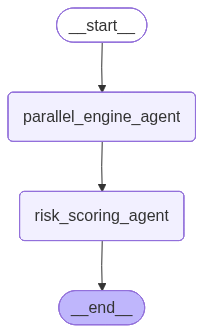

In [ ]:
kyc_app

## Run for one image

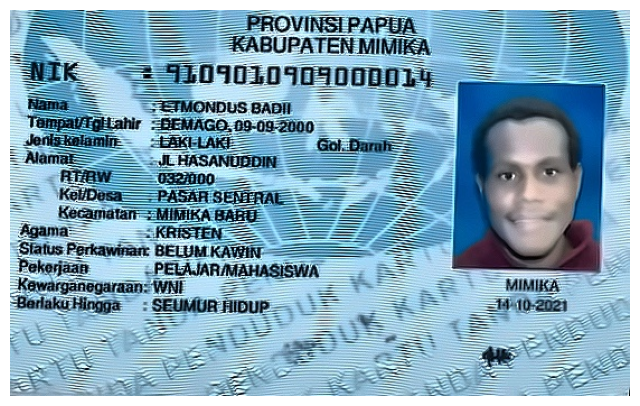

In [ ]:
import matplotlib.pyplot as plt

image_path = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/2d167783-ktp-54_jpg.rf.304f92a5bf8d1b1f660d24efa8d175fb.jpg"

# Read image
image = cv2.imread(image_path)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display
plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [ ]:
result = kyc_app.invoke({
    "preprocessed_id_image_path": "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/2d167783-ktp-54_jpg.rf.304f92a5bf8d1b1f660d24efa8d175fb.jpg",
})

result["final_decision"]

PROVINSIPAPEA EKABUPATENMIMIRA VIK 7109010709000014 EMONDUS BADII TANPMCTAHIR :@EMAG@ 09-09200O JENLELOIN ENLLAN GODARH NAMAR JLÉASANODDIN RÉBW (3200 KELLDASA PASRSEERAL KECAMATANMMRABAMD AGAMA KRISTEN SLALUS PERKAWIAN BELUMKAMIN PEKORJAAN PELAARMAHASISWA KAWARGANEGARAAN: WNI MIMIKA BERLAKU HLINOOA SEUMUR HIDUP {0-*2021


{'decision': 'approved',
 'risk_score': 0.31,
 'reason_codes': ['Date of Birth missing', 'Potential Photoshop manipulation'],
 'extracted_fields': {'id_number': '7109010709000014',
  'name': 'JLÉASANODDIN',
  'dob': None,
  'address': 'JLÉASANODDIN',
  'expiry_date': 'SEUMUR - HIDUP(lifetime)',
  'nationality': 'Indonesian'},
 'scores': {'ocr_confidence': 0.41,
  'document_validity_score': 0.8,
  'fraud_score': 0.44,
  'face_quality_score': 0.88,
  'face_detected_score': 1.0}}

In [ ]:
import pandas as pd
import json
from pathlib import Path

input_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean/"
output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/clean_extracted_data/"

##Supports .jpg or .jpeg or .png

image_paths = (
    glob.glob(os.path.join(input_folder, "*.jpg")) +
    glob.glob(os.path.join(input_folder, "*.jpeg")) +
    glob.glob(os.path.join(input_folder, "*.png"))
)

print("Total images found:", len(image_paths))

results = []

for image_path in image_paths:

            try:
                result = kyc_app.invoke({
                    "preprocessed_id_image_path": image_path
                })

                final_decision = result.get("final_decision", {})
                scores = final_decision.get("scores", {})
                extracted_fields = final_decision.get("extracted_fields", {})

                row = {
                    "image_path": image_path,
                    "decision": final_decision.get("decision"),
                    "risk_score": final_decision.get("risk_score"),
                    "reason_codes": " | ".join(final_decision.get("reason_codes", [])),

                    "ocr_confidence": scores.get("ocr_confidence"),
                    "document_validity_score": scores.get("document_validity_score"),
                    "fraud_score": scores.get("fraud_score"),
                    "face_quality_score": scores.get("face_quality_score"),
                    "face_detected_score": scores.get("face_detected_score"),

                    "extracted_fields_json": json.dumps(extracted_fields, ensure_ascii=False),
                    "full_result_json": json.dumps(result, ensure_ascii=False)
                }

                for key, value in extracted_fields.items():
                    row[f"field_{key}"] = value

                results.append(row)

            except Exception as e:
                results.append({
                    "image_path": image_path,
                    "decision": "error",
                    "risk_score": None,
                    "reason_codes": str(e),
                    "full_result_json": None
                })

Total images found: 201
PROVINSI A@EH KABUPATEN AGEH BARAT DAYA NIK 1112010402L10002 NAMA "DAEMI TEMPAUTGL LAHIR #BARUF 04 02 1984 JENIS KELAMIN :GAKI-UAKI GOL DAABI: ALAMAT DESA BARU RTIRW KELLDESE BARU KECAMATAN HEUMPA AGAMA ISLAM STALUS PERKAAWVINAN  KAWIN PEKERJAAN #PEANIPEKEEUN 7CH@ARTD KEWAARGANED@RAHENI 1503 BEITUFITIA 40218
X 8 AMIN ZAHIR 574035008900003 ROVINSI RTIRW KOTA :RIZKI ! KEVDESA  1 9 ' 1 :PEREMPUAN | PROBOLINGGO | 1 5 [ 002/ SERMA , WIROBORANG ; 1 1 ' 6 ABD 10 08-1990 8 PELAJARMMAHASISWA 1 UM = Í GOL DARAH 1 KAWIN ( PROPO
PROVINSI SULAWESI TENGGARA KOTA KENDARI NIK 4271014309010002 NAMA EMURNIATI AWALIA TEMPAYTGL LAHLR KENDARI, 03 03-2001 JENS KELAMIN GOL DARAL 20 ALAMAL PHHSUPUNSUFG @TW 8021001 KELDESA KORUMBA KECAMALAN MANDONGA AGAMA ISEAM STATUS PERKAWINAN: BELUMKAWIN PEKERJAAN PEEAJARMMAHASISWA KOTA KEVDAAI KEWARGANEGARAAN: WNI 16-042019 BERLAKU HINGGA SEUMUR HIDUP
PROVINSIACEH KOTALANGSA NIK 1L16075703970003 NANA MAATHA CYNTIA DEWI TEMGADTGL LAHIR #RAYEUK 175829

Traceback (most recent call last):
  File "/tmp/ipykernel_465/3725053851.py", line 40, in ocr_layout_agent
    "expiry_date": extract_expiry_date(full_text),
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_465/1378417164.py", line 10, in extract_expiry_date
    if splitter[i + 2].lower().startswith("seu"):
       ~~~~~~~~^^^^^^^
IndexError: list index out of range


PROVINSIDKI JAKARTA UAKARTA UTARA NIK 3173020311790005 NAMA WILIANTO AMIN TEMPATFTGL LAHIR PALEMBANG, 03-11-1979 KELAMNN LAKI-LAK GOL DARAH ,8 ALAMAR TAMAN GRISENDA BLOK FGNO: 11 ATIW 005010 KELDESA KAPUKMUARA KECAMATAN PENJARINGAN AGAMA BUDHA STATUS PERKAWINAN: KAWIN KERJAAN WIRASWASTA JAKAATAUTARA KEWVARGANEGARAAN:WNI 08-12-2017 BERAKUINGGA SEUMUR HIDUP |A KAR RAR PENDVOUK DRN
PROVINSI SUMATERA UTARA KABUPATEN BATUBARA NIK 1219015809020004 MHARNA WIDA SEPTIANA BA HAALMU TEINPAULQLSHE PANGKALAN DOUER, %8-84-2002 JERS HELAMIN PEREMPUAN S0 DARH NARAT ANPANGLA KUDA LXV AIAW 40*000 KAVDESA PNGKALAN DODFS BANU KOCAMALAN MEDAS EAA AUAME KNIS TEN STANUS PERKAVANAN BLLUM KAWIN PUKOIAAN BFLULTIDAK AEKENEA MIUBAAA KAUURGANOGARAN WHI BONAKU HINOGE SEUMUR HIOUP 22 0 2020 844
PROVINSI JAWA BARAT KABUPATENBANDUNG NIK 3204060308840003 ACU: WIONO TMOALBUV OKUIUA, 03-08-1984 LAKLLAKI GOL-DARH R, ENDANG SOEWANDANO I8^ ARAW 001/004 KADERA PADASUKA KCMALAR CIVENYAN ISLAN PURANAN KAWIN GURU BANDUNG KERAAN

Traceback (most recent call last):
  File "/tmp/ipykernel_465/3725053851.py", line 40, in ocr_layout_agent
    "expiry_date": extract_expiry_date(full_text),
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_465/1378417164.py", line 10, in extract_expiry_date
    if splitter[i + 2].lower().startswith("seu"):
       ~~~~~~~~^^^^^^^
IndexError: list index out of range


EDDOZ9SDH0?IZ HHI39NOMN?  HVSNAL NALYDNGVY ISNIAOH
K 6405026901040005 NAMA KEZIA CALLYSTAEIAENNE TEMPAVTOL LALUT NUNUKAN, 29-0632004 JENIS KELAMUN PEAEMPUAN GOEPARAH ALAMA DANRU JEMEANGMO SA RTIÑW 005I0O0 KEVLESAE PNMUSIAN KECAMATAN TAAAKAN TENGN AQAMA KAISTEN STATUS PEITAWINAN BELUM KAWIN PEKERJAAN PELAJARUMARASISWA KOTA TAHAKAN WARGANEGARAAN: WNI {009,2021 WHINGGA SEUMUA HIDUP KAK1 TEN QUOU #TV
PAOVI S5Y NIK 6D DVAH ISLA WM HIDUP AK HNONA MKARTA : 730005 70972 3174105 1 HENORAWATI MNONINO ' 17 021073 SUYEDANO, PEREVPUN IOCCAKEUAR ~MELATI 607100 NEUI BINTARO RTAW PESANGRAHN (JKARIASEALAN KAD KOCANALAN {CA MA1 ITNHOGA 'KAWIN AUMAHT CANA POUNNAN | NENGURUS = SEUVUA L
PAOVINSI SUMATEAAUTAAA KOTA TANJUNGBALMI NIK 127404420797D003 AN NUNUL( ADILAHPANITAN TOMNPAL IQILAHT [ARNGIALN 0071997 JENIS ACLAMN REHFHPUAA GAL DARAF NANAI AN UHNANUDOINUKIV RTIAW COENO KCDESA PEAGAN KECINLAN TELUK MIBNNG AQRU ISLA SULL PEILOBINAN BFLUMRAWIN PRHERHAAN PELAJA;MAIUASISHA KOTAIANUNGMALN KEWA DANCOATDAN: WMI

Traceback (most recent call last):
  File "/tmp/ipykernel_465/3725053851.py", line 40, in ocr_layout_agent
    "expiry_date": extract_expiry_date(full_text),
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_465/1378417164.py", line 10, in extract_expiry_date
    if splitter[i + 2].lower().startswith("seu"):
       ~~~~~~~~^^^^^^^
IndexError: list index out of range


AOVINSI JL IG GAL AGAMA WNI NIK 1 SULAWESI KOTA TENGAH 7271030210980001 PALU TOMPALLTOL LAIH HENRY ALEXANDER DARAWIA JONRS [ KOLAMIN PALU  ALAMAL -10-1998 LAKI-LAKI RTRW TURURUKANO KOVDESA DARN 003/002 KECAMALAN IATURAUTARA PALU SELATAN STALUS PERKAVNAN KAISTEN POKERPAAN BELUMKAWIN KNWRARGANOGARAAN PENJARNAHASISWA BODAKU HINOOA SEUMUR HIDUP KOIA PALU 11-01-2016
JEMGHEU LAHIR` HUNUIAN 29 06EUBENNE JENIS KELIMN POÑ@FN ALAMAL GOUDAIB RTIRW OCSDBOU TEMPANGMOHHA KEVDESH @AMUSAN KECAMATAN BAAMANTEVOE AGAMA KASTEN STALUS PETKAWAN BELUMKAWIN PEKERPAN PELAMHMMAFASISWA KEWARGANEGARAAN: LNI KOTA TARAKAN BORA LUCHINGGN SEUMUA TLPUP 09 2021
ENACEH BARAT DAYA 1LB2UALBUY "JODDA ATTGL LAHIR DERI SAFRI INAWAN  ~ENE KETAMIN UNG PADANG, 16-10 VAMAL LAKI-LAKI GOL DARAH UN ELANC 00OIDQI KEVDERA UJMGPADANS KECAMATAN MMGGENG AGAME ISLA SNATUS PEKAWINA ~ DELUMKAWIN POXERPAN FEL AJARIMAFASISWA KEWAROANEGATAAN; WNI ACE BARAT DAYA BERSKU SEUMUR HIDUP {8-09-2015 4980 ATIRW HINGYE
PROVINSIAWABAAAT KABUPATENBERSI I

In [ ]:
df = pd.DataFrame(results)

csv_path = output_folder+"kyc_results.csv"

df.to_csv(csv_path, index=False)

print("CSV saved to:", csv_path)

df.head()

CSV saved to: /content/drive/My Drive/kyc_train/after_preprocess_image/clean_extracted_data/kyc_results.csv


,image_path,decision,risk_score,reason_codes,ocr_confidence,document_validity_score,fraud_score,face_quality_score,face_detected_score,extracted_fields_json,full_result_json,field_id_number,field_name,field_dob,field_address,field_expiry_date,field_nationality
0,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.46,ID number missing | Date of Birth missing | Ex...,0.50,0.0,0.42,0.84,1.0,"{""id_number"": null, ""name"": ""\""DAEMI"", ""dob"": ...","{""preprocessed_id_image_path"": ""/content/drive...",None,"""DAEMI",None,Alamat RTIRW 7CH@ARTD,None,None
1,/content/drive/My Drive/kyc_train/after_prepro...,rejected,0.70,ID number missing | Name missing | Date of Bir...,0.57,0.0,0.37,0.00,0.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,RTIRW,None,None
2,/content/drive/My Drive/kyc_train/after_prepro...,approved,0.35,Date of Birth missing | Address missing | Pote...,0.56,0.4,0.41,0.90,1.0,"{""id_number"": ""4271014309010002"", ""name"": ""EMU...","{""preprocessed_id_image_path"": ""/content/drive...",4271014309010002,EMURNIATI AWALIA,None,None,SEUMUR - HIDUP(lifetime),Indonesian
3,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.45,ID number missing | Date of Birth missing | Ex...,0.49,0.0,0.38,0.82,1.0,"{""id_number"": null, ""name"": ""UNTUMARNOHE"", ""do...","{""preprocessed_id_image_path"": ""/content/drive...",None,UNTUMARNOHE,None,RTRW,None,Indonesian
4,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.52,ID number missing | Name missing | Date of Bir...,0.38,0.0,0.29,0.69,0.5,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,None,None,None


In [ ]:
df['decision'].value_counts()

,count
decision,
approved,90
manual_review,83
rejected,28


In [ ]:
df.groupby('decision')['field_id_number'].apply(lambda x: x.isnull().sum())

,field_id_number
decision,
approved,22
manual_review,46
rejected,25


In [ ]:
df.groupby('decision')['field_name'].apply(lambda x: x.isnull().sum())

,field_name
decision,
approved,59
manual_review,72
rejected,26


In [ ]:
input_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/warp/"
output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/warp_extracted_data/"

##Supports .jpg or .jpeg or .png

image_paths = (
    glob.glob(os.path.join(input_folder, "*.jpg")) +
    glob.glob(os.path.join(input_folder, "*.jpeg")) +
    glob.glob(os.path.join(input_folder, "*.png"))
)

print("Total images found:", len(image_paths))

results = []

for image_path in image_paths:

            try:
                result = kyc_app.invoke({
                    "preprocessed_id_image_path": image_path
                })

                final_decision = result.get("final_decision", {})
                scores = final_decision.get("scores", {})
                extracted_fields = final_decision.get("extracted_fields", {})

                row = {
                    "image_path": image_path,
                    "decision": final_decision.get("decision"),
                    "risk_score": final_decision.get("risk_score"),
                    "reason_codes": " | ".join(final_decision.get("reason_codes", [])),

                    "ocr_confidence": scores.get("ocr_confidence"),
                    "document_validity_score": scores.get("document_validity_score"),
                    "fraud_score": scores.get("fraud_score"),
                    "face_quality_score": scores.get("face_quality_score"),
                    "face_detected_score": scores.get("face_detected_score"),

                    "extracted_fields_json": json.dumps(extracted_fields, ensure_ascii=False),
                    "full_result_json": json.dumps(result, ensure_ascii=False)
                }

                for key, value in extracted_fields.items():
                    row[f"field_{key}"] = value

                results.append(row)

            except Exception as e:
                results.append({
                    "image_path": image_path,
                    "decision": "error",
                    "risk_score": None,
                    "reason_codes": str(e),
                    "full_result_json": None
                })

Total images found: 201
PROVINSI ACEH KABUPATEN ACEH BARAT DAYA NIK 1112010402610002 NAMA ARMI TEMPAUTGL LAHIR BARU; 04-02-1961 JENIS KELAMIN LAKI-LAKI GOLDERAH ALAMAT DESA BARU RTIRW KEVDESE BARU KECAMATAN JEUMPA AGAMA ISLAM STALUS PERKAWVINAN KAWIN PEKERJAAN PETANIIPEKEBUN ACEH BARAT DAYA KEWARGANEGARAAN; WNI 11 03 2013 BERLAKU HINGGA 04-02-2018
%HI 8 6 74 3 AIIN ROVINSI RTRW 740350085 KOTA KEVDESA RIZKI FIRMANANDA 1 1 9 PROBOLINGGO, 1 PEREMPUAN PROBOLINGGO | 1 5 [ 8 F WIROBORANG 1 O04 ,900003 1 ' ABD [ BEL : 1 UM 8 Í 1 AJARMAHASISWA 1 10-08-2017 KOTA ] PROP'
PROVINSI SULAWESI TENGGARA KOTA KENDARI NIK 7471014303010002 NAMA MUANIATI AWALIA TEMPAUTGL LAHIR KENDARI, 03-03-2001 JENIS KELAMIN PEREMPUAN GOLDARAH ALAMAL JH SUPU YUSUF RTRW 002/001 KELDESA KOHUMBA KECAMATAN MANDONGA AGAMA ISLAM STALUS PERKAWINAN: BELUM KAWIN PEKERJAAN PELAMARIMAHASISWA KOTA KENDAAI KEWARGANEGARAAN: WNI 16-04-2019 BERLAKU HINGGA SEUMUR HIDUP ;AF; ?UNVN ~3U
PROVINSI ACEH KOTA LANGSA NIK 1116075703970003 VANA M

In [ ]:
df_2 = pd.DataFrame(results)

csv_path = output_folder+"kyc_results.csv"

df_2.to_csv(csv_path, index=False)

print("CSV saved to:", csv_path)

df_2.head()

CSV saved to: /content/drive/My Drive/kyc_train/after_preprocess_image/warp_extracted_data/kyc_results.csv


,image_path,decision,risk_score,reason_codes,ocr_confidence,document_validity_score,fraud_score,face_quality_score,face_detected_score,extracted_fields_json,full_result_json,field_id_number,field_name,field_dob,field_address,field_expiry_date,field_nationality
0,/content/drive/My Drive/kyc_train/after_prepro...,approved,0.21,ID face image quality is low | ID face region ...,0.77,1.00,0.21,0.52,1.0,"{""id_number"": ""1112010402610002"", ""name"": ""ARM...","{""preprocessed_id_image_path"": ""/content/drive...",1112010402610002,ARMI,04-02-1961,Alamat RTIRW,04-02-2018,Indonesian
1,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.64,ID number missing | Name missing | Expiry date...,0.62,0.00,0.21,0.00,0.0,"{""id_number"": null, ""name"": null, ""dob"": ""10-0...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,10-08-2017,RTRW,None,None
2,/content/drive/My Drive/kyc_train/after_prepro...,approved,0.21,ID face region appears blurry,0.69,1.00,0.24,0.61,1.0,"{""id_number"": ""7471014303010002"", ""name"": ""MUA...","{""preprocessed_id_image_path"": ""/content/drive...",7471014303010002,MUANIATI AWALIA,03-03-2001,RTRW,SEUMUR - HIDUP(lifetime),Indonesian
3,/content/drive/My Drive/kyc_train/after_prepro...,approved,0.36,Name missing | Date of Birth missing | ID face...,0.47,0.55,0.23,0.50,1.0,"{""id_number"": ""1116075703970003"", ""name"": null...","{""preprocessed_id_image_path"": ""/content/drive...",1116075703970003,None,None,AtRW,SEUVUR - HIDUP(lifetime),Indonesian
4,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.46,ID number missing | Name missing | Date of Bir...,0.32,0.00,0.19,0.65,1.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,None,None,None


In [ ]:
df_2['decision'].value_counts()

,count
decision,
manual_review,106
approved,77
rejected,18


In [ ]:
df_2.groupby('decision')['field_id_number'].apply(lambda x: x.isnull().sum())

,field_id_number
decision,
approved,12
manual_review,46
rejected,16


In [ ]:
df_2.groupby('decision')['field_name'].apply(lambda x: x.isnull().sum())

,field_name
decision,
approved,40
manual_review,92
rejected,18


In [ ]:
input_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/text_ready/"
output_folder = "/content/drive/My Drive/kyc_train/after_preprocess_image/text_ready_data/"

##Supports .jpg or .jpeg or .png

image_paths = (
    glob.glob(os.path.join(input_folder, "*.jpg")) +
    glob.glob(os.path.join(input_folder, "*.jpeg")) +
    glob.glob(os.path.join(input_folder, "*.png"))
)

print("Total images found:", len(image_paths))

results = []

for image_path in image_paths:

            try:
                result = kyc_app.invoke({
                    "preprocessed_id_image_path": image_path
                })

                final_decision = result.get("final_decision", {})
                scores = final_decision.get("scores", {})
                extracted_fields = final_decision.get("extracted_fields", {})

                row = {
                    "image_path": image_path,
                    "decision": final_decision.get("decision"),
                    "risk_score": final_decision.get("risk_score"),
                    "reason_codes": " | ".join(final_decision.get("reason_codes", [])),

                    "ocr_confidence": scores.get("ocr_confidence"),
                    "document_validity_score": scores.get("document_validity_score"),
                    "fraud_score": scores.get("fraud_score"),
                    "face_quality_score": scores.get("face_quality_score"),
                    "face_detected_score": scores.get("face_detected_score"),

                    "extracted_fields_json": json.dumps(extracted_fields, ensure_ascii=False),
                    "full_result_json": json.dumps(result, ensure_ascii=False)
                }

                for key, value in extracted_fields.items():
                    row[f"field_{key}"] = value

                results.append(row)

            except Exception as e:
                results.append({
                    "image_path": image_path,
                    "decision": "error",
                    "risk_score": None,
                    "reason_codes": str(e),
                    "full_result_json": None
                })

Total images found: 201
EWDEZLANIL REVG@GL
8 8 02* 479035008 6 #BOVINSDAWAL 2 P 1 BEMIGIRMANAADE 1 1 8 @LD@@NCGG 7 @EREMEU PROBOLINGGO | 1 1 8 MOECNMO 2 1 50000A 8 TIMUR ISLAM 7@D 1 PELAIARAY @MMM 5 8 #SSVTA
@@MEISHLÄWESITEMOGARA K@@A#ÄÜZ~RÄ ERL 'K@AXEVDEAI
US S VEAA?D UFPPVXNSIACÜ! KOMDAGSL 2760752@9170@PE URTFLC@74PE @IWYENI 4 #PEQEL FTUM 4W4E=Y= EE@K@NEEE 5ECS2IDS UKET 42 REIN EXIY@= 55204 EXGUALNGSA 35200
5 2 1 0 1 " 8 1 ; ; # 3 3
4Ë624T 92A3PUS9UUNO
MNSI KALIMANTAN TWUR KABUPATENBEMD 64DA0SO40ZBODUOZ #RUSMAR TEUL '8EBTT 2 ATMW; KOYOOSG; 'KEAMA

BEOVINSLAWAEAWA @BUPATNG #O30I5UAU1 @OHUIGHEN 15@N5 EE @65 405/62 W2 E0 442252 027 "V 4G20UEENUMAA@E Ç4STTN 2AARI GIANN 12X@
KABUPRPYIASLEFEHNGKAL 51J00L)UOUOZUBOLY 2IA1SO? KAWIN 'ACEHSNGK#: GWFUZJX
BAGO EUNSNX FKABUPATE 0I010 M0SB 0900 {IMIK?

@25577 #IESI4NISDI
#EDOLTEILA) TJ2AU #GANYAA 74074Q740U4? ZATUS MINAR
PROVINSIDKI JAKARTA OJAKARTAUTARA NIK 41730203112900052 #GMG  #WLAN7QAMN IUAHK BUANDHA "4 CVI TAGVGBGENBTEI 22F4E24DIHI + #AKARTA

In [ ]:
df_3 = pd.DataFrame(results)

csv_path = output_folder+"kyc_results.csv"

df_3.to_csv(csv_path, index=False)

print("CSV saved to:", csv_path)

df_3.head()

CSV saved to: /content/drive/My Drive/kyc_train/after_preprocess_image/text_ready_data/kyc_results.csv


,image_path,decision,risk_score,reason_codes,ocr_confidence,document_validity_score,fraud_score,face_quality_score,face_detected_score,extracted_fields_json,full_result_json,field_id_number,field_name,field_dob,field_address,field_expiry_date,field_nationality
0,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.58,ID number missing | Name missing | Date of Bir...,0.02,0.0,0.43,0.75,1.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,None,None,None
1,/content/drive/My Drive/kyc_train/after_prepro...,rejected,0.79,ID number missing | Name missing | Date of Bir...,0.37,0.0,0.54,0.00,0.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,None,None,None
2,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.56,ID number missing | Name missing | Date of Bir...,0.06,0.0,0.44,0.80,1.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,None,None,None
3,/content/drive/My Drive/kyc_train/after_prepro...,manual_review,0.56,ID number missing | Name missing | Date of Bir...,0.12,0.0,0.46,0.77,1.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,uRTflC@74pE,None,None
4,/content/drive/My Drive/kyc_train/after_prepro...,rejected,0.66,ID number missing | Name missing | Date of Bir...,0.38,0.0,0.51,0.58,0.0,"{""id_number"": null, ""name"": null, ""dob"": null,...","{""preprocessed_id_image_path"": ""/content/drive...",None,None,None,None,None,None


In [ ]:
df_3['decision'].value_counts()

,count
decision,
rejected,105
manual_review,96


In [ ]:
df_3.groupby('decision')['field_id_number'].apply(lambda x: x.isnull().sum())

,field_id_number
decision,
manual_review,69
rejected,78


In [ ]:
df_3.groupby('decision')['field_name'].apply(lambda x: x.isnull().sum())

,field_name
decision,
manual_review,94
rejected,100
